In [ ]:
import tidy3d as td


In [ ]:
import tidy3d.web as web


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print(td.__version__)

In [ ]:
import tidy3d as td
import tidy3d.web as web
import numpy as np
import matplotlib.pyplot as plt
from tidy3d.constants import C_0

# =========================
# Waveguide parameters
# =========================
core_width = 0.50        # um
core_thickness = 0.22    # um
core_n = 3.48            # silicon
clad_n = 1.44            # SiO2

# Wavelength range around C-band
wavelengths = np.array([1.50, 1.525, 1.55, 1.575, 1.60])  # um
freqs = C_0 / wavelengths

# =========================
# Materials
# =========================
clad_medium = td.Medium(
    name="SiO2_cladding",
    permittivity=clad_n**2,
)

core_medium = td.Medium(
    name="Silicon_core",
    permittivity=core_n**2,
)

# =========================
# Waveguide geometry
# Propagation direction: x
# Cross-section: y-z plane
# =========================
waveguide = td.Structure(
    geometry=td.Box(
        size=[td.inf, core_width, core_thickness]
    ),
    name="silicon_waveguide",
    medium=core_medium,
)

# =========================
# Mode simulation
# =========================
sim = td.ModeSimulation(
    plane=td.Box(size=[0, 4, 3]),
    freqs=freqs,
    mode_spec=td.ModeSpec(
        num_modes=4,
        group_index_step=True,
    ),
    size=[0, 4, 3],
    boundary_spec=td.BoundarySpec(
        x=td.Boundary.pml(),
        y=td.Boundary.pml(),
        z=td.Boundary.pml(),
    ),
    grid_spec=td.GridSpec.auto(
        min_steps_per_wvl=20,
        wavelength=1.55,
    ),
    medium=clad_medium,
    structures=[waveguide],
)

# Plot cross-section before running
sim.plot(x=0)
plt.title("Silicon Strip Waveguide Cross-section")
plt.show()

# Run cloud simulation
sim_data = web.run(
    sim,
    task_name="silicon_strip_waveguide_MODE",
    path="./data/silicon_strip_waveguide_mode.hdf5",
)

In [2]:
print(sim_data.n_eff)

AttributeError: 'ModeSimulationData' object has no attribute 'n_eff'

In [9]:
modes = sim_data.modes_raw

print(type(modes))
print(modes)
print(dir(modes))

<class 'tidy3d.components.data.monitor_data.ModeSolverData'>
ModeSolverData(
    Ex=<xarray.ScalarModeFieldDataArray (x: 1, y: 94, z: 69, f: 5, mode_index: 
4)> Size: 2MB
array([[[[[ 0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j],
          [ 0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j],
          [ 0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j],
          [ 0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j],
          [ 0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.00000000e+00j,
            0.00000000e+00+0.0000

In [11]:
n_eff = np.real(modes.n_complex)
print(n_eff)

<xarray.ModeIndexDataArray (f: 5, mode_index: 4)> Size: 160B
array([[2.49605084, 1.84325758, 1.52773151, 1.41064926],
       [2.47040549, 1.80922701, 1.50893985, 1.40934574],
       [2.44457974, 1.77716084, 1.49292152, 1.40802021],
       [2.41858332, 1.74712445, 1.47932515, 1.40666978],
       [2.39242709, 1.71914629, 1.46783323, 1.40529189]])
Coordinates:
  * f           (f) float64 40B 1.999e+14 1.966e+14 ... 1.903e+14 1.874e+14
  * mode_index  (mode_index) int64 32B 0 1 2 3
Attributes:
    long_name:  Propagation index


In [12]:
# Find the index corresponding to 1.55 um
idx_1550 = np.where(np.isclose(wavelengths, 1.55))[0][0]

neff_1550_mode0 = n_eff.values[idx_1550, 0]

print(f"At wavelength = 1.55 um:")
print(f"Fundamental mode effective index n_eff = {neff_1550_mode0:.4f}")

At wavelength = 1.55 um:
Fundamental mode effective index n_eff = 2.4446


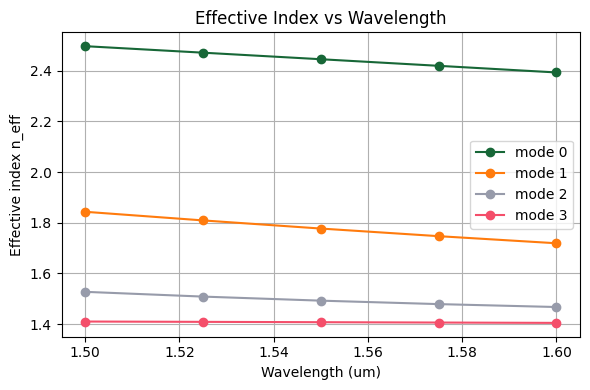

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

for i in range(n_eff.shape[1]):
    plt.plot(wavelengths, n_eff.values[:, i], marker="o", label=f"mode {i}")

plt.xlabel("Wavelength (um)")
plt.ylabel("Effective index n_eff")
plt.title("Effective Index vs Wavelength")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# hahaha